Original Churn values: [0 1]
Final target values:
 Churn
0    74
1     3
Name: count, dtype: int64


/tmp/ipykernel_7018/2140310263.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Churn'] = data['Churn'].replace({


AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 0.9375


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


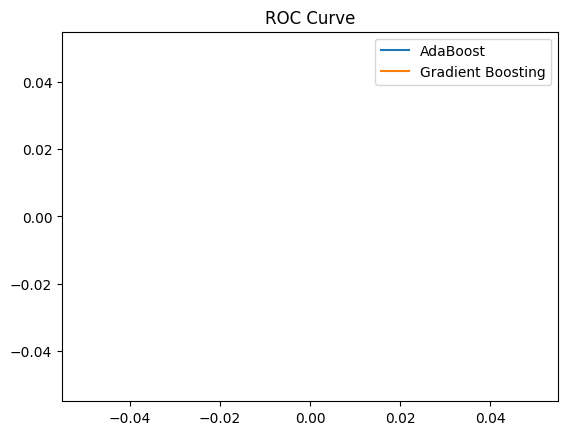

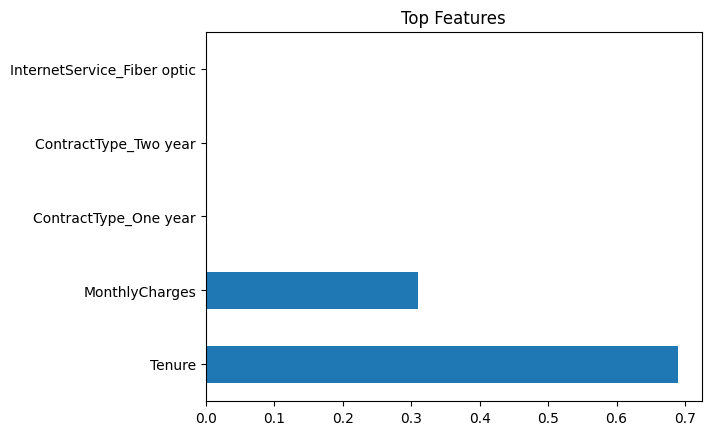

In [3]:
# Name: Navithanjali
# Roll No: 24BAD077
# Scenario 2 - Boosting (FINAL FINAL FIX)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve

# ------------------ Load Dataset ------------------
data = pd.read_csv("churn_boosting - Copy.csv")

# Clean column names
data.columns = data.columns.str.strip()

# ------------------ CHECK TARGET VALUES ------------------
print("Original Churn values:", data['Churn'].unique())

# ------------------ FIX TARGET COLUMN ------------------
data['Churn'] = data['Churn'].astype(str).str.strip().str.lower()

# Convert ANY format to 0/1
data['Churn'] = data['Churn'].replace({
    'yes': 1, 'no': 0,
    'y': 1, 'n': 0,
    '1': 1, '0': 0
})

# Remove rows where conversion failed
data = data[data['Churn'].isin([0, 1])]

# ------------------ Fix TotalCharges ------------------
if 'TotalCharges' in data.columns:
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Drop remaining NaN
data = data.dropna()

# ------------------ Convert categorical ------------------
data = pd.get_dummies(data, drop_first=True)

# ------------------ Features & Target ------------------
X = data.drop("Churn", axis=1)
y = data["Churn"]

# CHECK AGAIN
print("Final target values:\n", y.value_counts())

# ------------------ Train Test Split ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------ AdaBoost ------------------
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

# ------------------ Gradient Boosting ------------------
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# ------------------ Accuracy ------------------
print("AdaBoost Accuracy:", accuracy_score(y_test, ada.predict(X_test)))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb.predict(X_test)))

# ------------------ ROC Curve ------------------
from sklearn.metrics import roc_curve

y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.legend()
plt.title("ROC Curve")
plt.show()

# ------------------ Feature Importance ------------------
import pandas as pd

feat_imp = pd.Series(gb.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

Original Churn values: [0 1]

Final target distribution:
 Churn
0    74
1     3
Name: count, dtype: int64

Train distribution:
 Churn
0    59
1     2
Name: count, dtype: int64

Test distribution:
 Churn
0    15
1     1
Name: count, dtype: int64

AdaBoost Accuracy: 0.9375
Gradient Boosting Accuracy: 1.0

AdaBoost Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16


Gradient Boosting Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         1

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


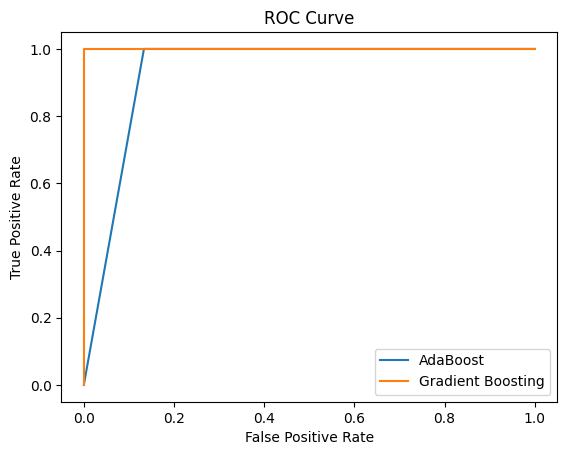

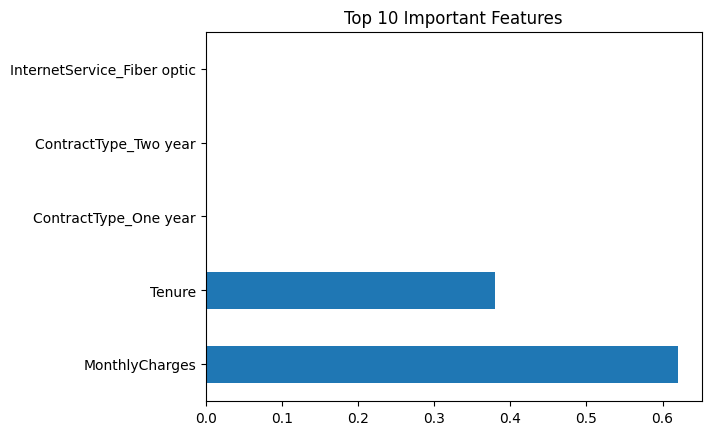

In [4]:
# Name: Navithanjali
# Roll No: 24BAD077
# Scenario 2 - Boosting (AdaBoost & Gradient Boosting)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, classification_report

# ------------------ Load Dataset ------------------
data = pd.read_csv("churn_boosting - Copy.csv")

# ------------------ Cleaning ------------------

# Remove spaces in column names
data.columns = data.columns.str.strip()

# Check original values
print("Original Churn values:", data['Churn'].unique())

# Since your dataset already has 0 and 1 → no mapping needed
# Just ensure numeric
data['Churn'] = pd.to_numeric(data['Churn'], errors='coerce')

# Remove invalid rows
data = data.dropna(subset=['Churn'])

# Fix TotalCharges if present
if 'TotalCharges' in data.columns:
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Drop remaining missing values
data = data.dropna()

# Convert categorical features
data = pd.get_dummies(data, drop_first=True)

# ------------------ Features & Target ------------------
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("\nFinal target distribution:\n", y.value_counts())

# ------------------ Train Test Split (STRATIFIED) ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

# ------------------ AdaBoost ------------------
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

# ------------------ Gradient Boosting ------------------
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# ------------------ Predictions ------------------
y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)

# ------------------ Accuracy ------------------
print("\nAdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

# ------------------ Classification Report ------------------
print("\nAdaBoost Report:\n", classification_report(y_test, y_pred_ada))
print("\nGradient Boosting Report:\n", classification_report(y_test, y_pred_gb))

# ------------------ ROC Curve ------------------
y_prob_ada = ada.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ------------------ Feature Importance ------------------
feat_imp = pd.Series(gb.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()